# Final Result Visuals

1. **Primary / Secondary KPI reporting** — RMSE and MAPE.
2. **Player-level market inefficiency analysis** — who's underpaid/overpaid, normalized by contract size (not raw dollars), plus a predicted-vs-actual fit chart.
3. **Fairness check across contract scale** — MAPE broken out by contract group, since the data audit flagged hardship contracts as structurally unlearnable from performance alone.
4. **Team-level ROI (Cost Per Win)** — Actual cost per win is calculated CPW = Actual Total Team Payroll / Actual Number of Wins, predicted cost per win is calulcated CPW = Predicted Total Team Payroll / Actual Number of Wins.
5. **Feature importance** — a credibility/interpretability chart for non-technical stakeholders (GMs, agents).

**Note on the ROI metric:** this notebook uses **team wins**, not win shares, as the on-court output side of the ROI calculation. Team wins is a raw, observed outcome, so **Cost Per Win (CPW)** is only based on our modeling: only the payroll numerator (actual vs. predicted) changes between the two
versions of the metric; the wins denominator is the same real number either way.

**Where team wins come from:** the processed test matrix doesn't reliably carry a team win-total
column, so this notebook pulls it directly from the raw `{year}_wnba_standings.csv` file and
merges it onto predictions by team abbreviation.


## Setup

In [3]:
from pathlib import Path
import re

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

raw_dir = ROOT / "data" / "raw"
processed_dir = ROOT / "data" / "processed"
artifact_dir = ROOT / "artifacts"
final_result_dir = ROOT / "results"
figures_dir = final_result_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


## Load Final Pipeline Outputs


In [4]:
metrics_df = pd.read_csv(final_result_dir / "final_metrics.csv")
pred_df = pd.read_csv(final_result_dir / "final_predictions.csv")
model_bundle = joblib.load(artifact_dir / "final_model.joblib")

final_model = model_bundle["model"]
feature_names = model_bundle["feature_names"]

print("Loaded final_metrics.csv, final_predictions.csv, and final_model.joblib")
display(metrics_df)


Loaded final_metrics.csv, final_predictions.csv, and final_model.joblib


,model,train_years,test_year,n_train,n_test,n_features,RMSE,MAE,MAPE,R2,residual_definition
0,RandomForestRegressor,2021-2024,2025,742,223,25,41368.597846,30376.251304,1.287013,0.634203,predicted - actual


## Headline KPI Reporting (RMSE / MAPE)


In [5]:
primary_kpi = metrics_df.loc[0, "RMSE"]
secondary_kpi = metrics_df.loc[0, "MAPE"]

print(f"Primary KPI  (RMSE): ${primary_kpi:,.2f}")
print(f"Secondary KPI (MAPE): {secondary_kpi * 100:.2f}%")
print(f"Model: {metrics_df.loc[0, 'model']}  |  Train years: {metrics_df.loc[0, 'train_years']}  |  Test year: {metrics_df.loc[0, 'test_year']}")


Primary KPI  (RMSE): $41,368.60
Secondary KPI (MAPE): 128.70%
Model: RandomForestRegressor  |  Train years: 2021-2024  |  Test year: 2025


## Player-Level Market Inefficiency Analysis

`final_predictions.csv` already has `residual = predicted - actual`, so a large **positive**
residual means the model thinks a player's fair-value salary is higher than what she's actually
paid — i.e. she's **underpaid** relative to her production. A large **negative** residual means
 her actual salary exceeds the model's fair-value estimate, i.e. she's **overpaid**.

Raw dollar residuals aren't directly comparable across a $70k rookie deal and a $250k supermax
deal, so two columns are added here:

- `value_pct = residual / actual` — the valuation gap normalized by contract size.
- `valuation_tag` — a label (`Underpaid` / `Fair` / `Overpaid`) using a ±15% threshold
  on `value_pct`.
  
All downstream rankings use `value_pct`, not raw `residual`, for exactly this reason.


In [6]:
VALUE_THRESHOLD = 0.15  # +/-15% banding for the Fair / Under / Over tag

pred_df["value_pct"] = pred_df["residual"] / pred_df["actual"]

def tag_valuation(pct):
    # residual = predicted - actual, so a positive value_pct means the model's fair-value
    # estimate is HIGHER than what she's actually paid -- i.e. she is underpaid.
    # A negative value_pct means actual pay exceeds the model's fair value -- overpaid.
    if pct >= VALUE_THRESHOLD:
        return "Underpaid"
    elif pct <= -VALUE_THRESHOLD:
        return "Overpaid"
    return "Fair"

pred_df["valuation_tag"] = pred_df["value_pct"].apply(tag_valuation)

print(pred_df["valuation_tag"].value_counts())
display(pred_df.head())


valuation_tag
Underpaid    107
Fair          68
Overpaid      48
Name: count, dtype: int64


,player,team,year,group,actual,predicted,residual,abs_error,value_pct,valuation_tag
0,A'ja Wilson,LVA,2025,veteran,200000,214155.701628,14155.701628,14155.701628,0.070779,Fair
1,Napheesa Collier,MIN,2025,unknown,214284,200972.099195,-13311.900805,13311.900805,-0.062123,Fair
2,Kelsey Mitchell,IND,2025,veteran,269244,213155.488619,-56088.511381,56088.511381,-0.208319,Overpaid
3,Kelsey Plum,LAS,2025,veteran,202000,214220.125809,12220.125809,12220.125809,0.060496,Fair
4,Paige Bueckers,DAL,2025,rookie,78831,121931.589132,43100.589132,43100.589132,0.546747,Underpaid


### Predicted vs. Actual Salary


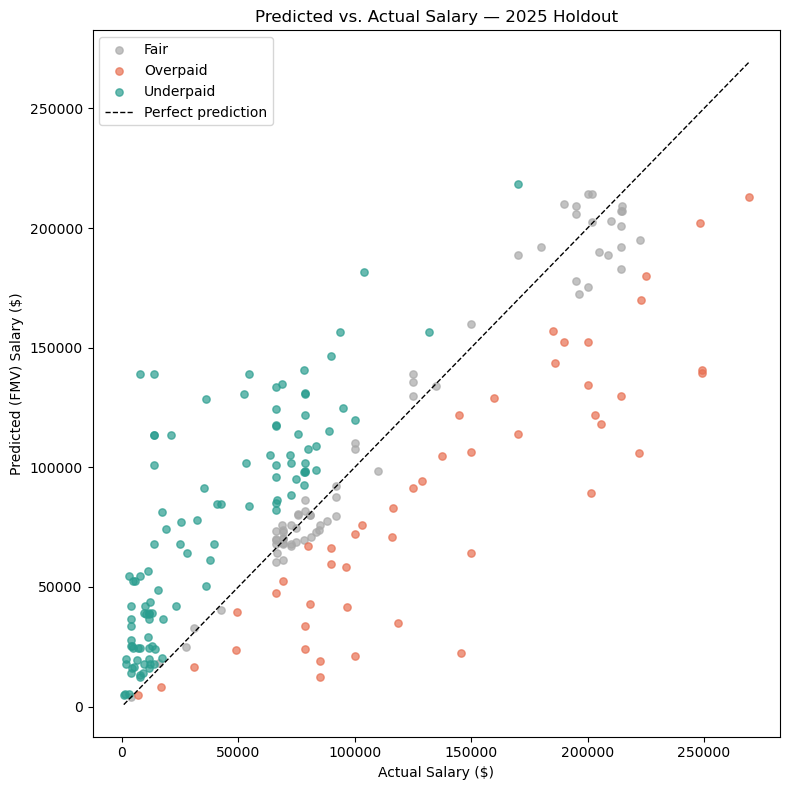

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = {"Underpaid": "#2a9d8f", "Fair": "#a8a8a8", "Overpaid": "#e76f51"}
for tag, group in pred_df.groupby("valuation_tag"):
    ax.scatter(group["actual"], group["predicted"], s=28, alpha=0.7, label=tag, color=colors.get(tag, "gray"))

lims = [
    min(pred_df["actual"].min(), pred_df["predicted"].min()),
    max(pred_df["actual"].max(), pred_df["predicted"].max()),
]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1, label="Perfect prediction")

ax.set_xlabel("Actual Salary ($)")
ax.set_ylabel("Predicted (FMV) Salary ($)")
ax.set_title("Predicted vs. Actual Salary — 2025 Holdout")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "predicted_vs_actual.png", dpi=150)
plt.show()


### Most Undervalued / Overvalued Players


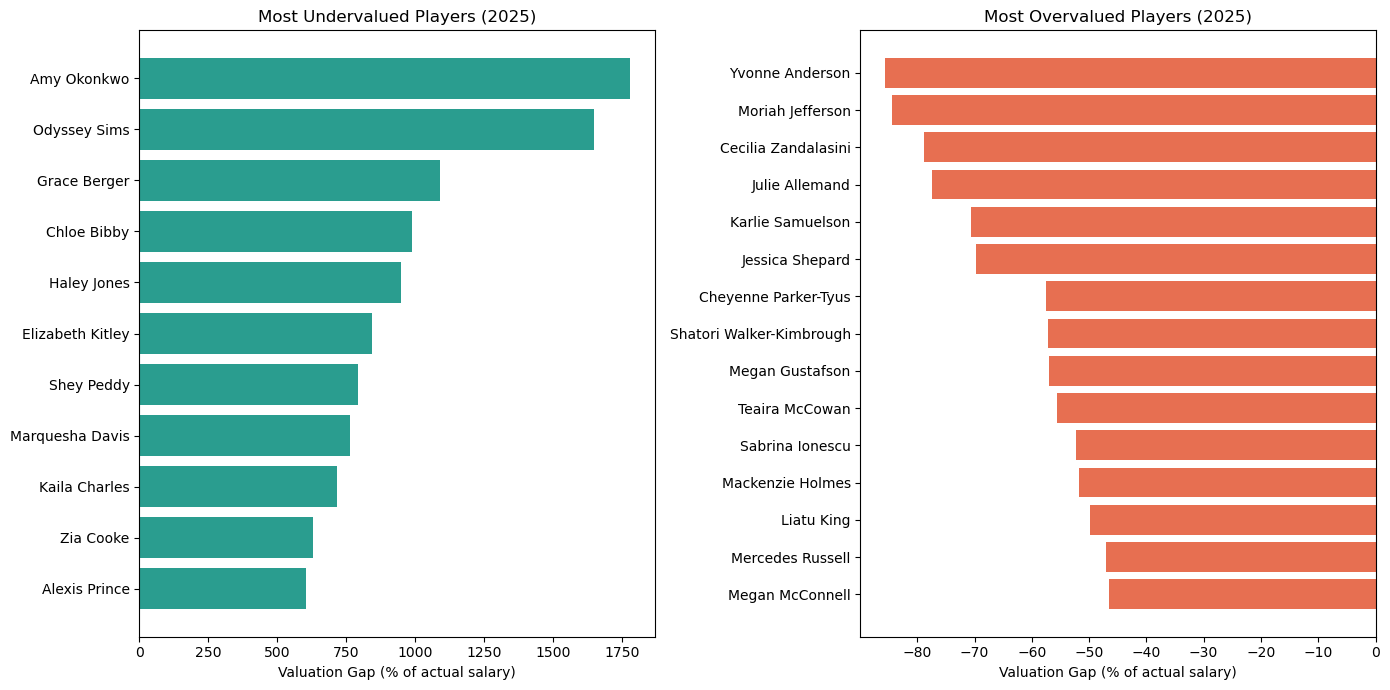

,player,team,group,actual,predicted,value_pct
46,Amy Okonkwo,DAL,veteran,2915,54734.313233,17.776780
54,Odyssey Sims,TOT,veteran,7949,138897.386595,16.473567
156,Grace Berger,TOT,hardship,1666,19834.808579,10.905647
129,Chloe Bibby,TOT,veteran,3887,42231.841580,9.864894
93,Haley Jones,TOT,hardship,4998,52447.527817,9.493703
53,Odyssey Sims,TOT,veteran,13911,138897.386595,8.984716
92,Haley Jones,TOT,hardship,5553,52447.527817,8.444900
196,Elizabeth Kitley,LVA,veteran,3887,36604.681087,8.417206
122,Shey Peddy,TOT,hardship,1987,17733.682005,7.924853
207,Marquesha Davis,TOT,veteran,3887,33502.741115,7.619177


,player,team,group,actual,predicted,value_pct
221,Yvonne Anderson,MIN,veteran,85000,12216.423824,-0.856277
194,Moriah Jefferson,CHI,veteran,145500,22577.850691,-0.844826
48,Cecilia Zandalasini,GSV,hardship,100000,21231.102565,-0.787689
116,Julie Allemand,LAS,hardship,85000,19240.640270,-0.773640
158,Karlie Samuelson,MIN,veteran,118450,34809.561242,-0.706124
76,Jessica Shepard,MIN,hardship,78831,23901.315633,-0.696803
75,Cheyenne Parker-Tyus,LVA,veteran,78831,33495.711904,-0.575095
186,Shatori Walker-Kimbrough,ATL,veteran,150000,64335.455415,-0.571097
164,Megan Gustafson,LVA,veteran,96820,41659.740957,-0.569720
112,Teaira McCowan,DAL,veteran,201400,89401.316216,-0.556101


In [8]:
top_underpaid = pred_df.sort_values("value_pct", ascending=False).head(15)
top_overpaid = pred_df.sort_values("value_pct").head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)

axes[0].barh(top_underpaid["player"], top_underpaid["value_pct"] * 100, color="#2a9d8f")
axes[0].invert_yaxis()
axes[0].set_title("Most Undervalued Players (2025)")
axes[0].set_xlabel("Valuation Gap (% of actual salary)")

axes[1].barh(top_overpaid["player"], top_overpaid["value_pct"] * 100, color="#e76f51")
axes[1].invert_yaxis()
axes[1].set_title("Most Overvalued Players (2025)")
axes[1].set_xlabel("Valuation Gap (% of actual salary)")

fig.tight_layout()
fig.savefig(figures_dir / "player_valuation_leaderboard.png", dpi=150)
plt.show()

display(top_underpaid[["player", "team", "group", "actual", "predicted", "value_pct"]])
display(top_overpaid[["player", "team", "group", "actual", "predicted", "value_pct"]])


## Fairness Check: Error by Contract Group (Secondary KPI)

The data audit flagged hardship contracts as a structural failure point — they're CBA-fixed at
very low values that bear no relationship to on-court performance, so every model defaults to
predicting league-average salaries for them. This section gives a documented reason to footnote
or exclude hardship contracts from headline metrics.


,n,median_actual_salary,mape
group,,,
hardship,20,6630.5,289.7
veteran,133,78831.0,156.0
controlled,13,66079.0,64.1
unknown,17,78066.0,37.3
rookie,40,75276.0,17.1


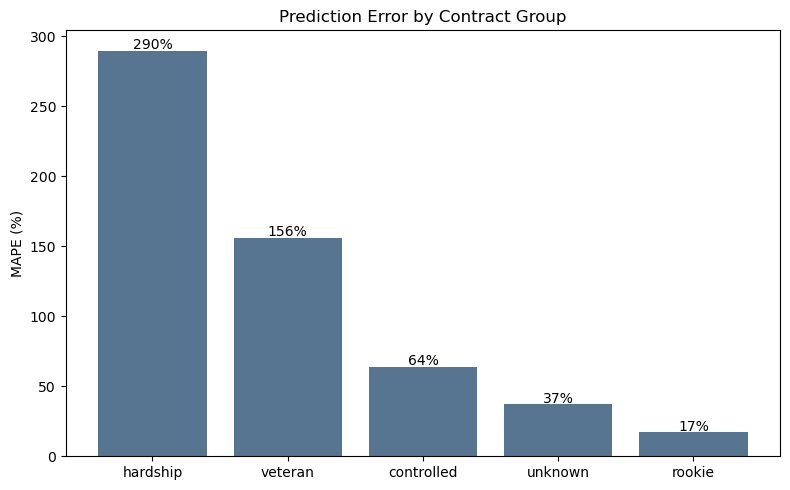

In [9]:
group_mape = (
    pred_df.assign(pct_error=lambda d: (d["abs_error"] / d["actual"]))
    .groupby("group")
    .agg(n=("player", "count"), median_actual_salary=("actual", "median"), mape=("pct_error", "mean"))
    .sort_values("mape", ascending=False)
)
group_mape["mape"] = (group_mape["mape"] * 100).round(1)

display(group_mape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(group_mape.index, group_mape["mape"], color="#577590")
ax.set_ylabel("MAPE (%)")
ax.set_title("Prediction Error by Contract Group")
for i, v in enumerate(group_mape["mape"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
fig.tight_layout()
fig.savefig(figures_dir / "mape_by_contract_group.png", dpi=150)
plt.show()


## Merge Team Wins for Team-Level ROI

`final_predictions.csv` carries `player, team, year, group, actual, predicted, residual,
abs_error` — no team win-total column, so Cost Per Win can't be computed yet. Rather than relying
on the processed feature matrix (which may not carry team wins as a clean, reliably-named
column), team wins are pulled straight from the raw `{test_year}_wnba_standings.csv` file and
merged onto predictions **by team abbreviation**, the same approach the data-loading pipeline
uses elsewhere in this project. Merging by key rather than row position also means there's no
row-order assumption to worry about here.


In [10]:
test_year = int(metrics_df.loc[0, "test_year"])

teammap = {
    "Atlanta Dream": "ATL", "Chicago Sky": "CHI", "Connecticut Sun": "CON",
    "Dallas Wings": "DAL", "Golden State Valkyries": "GSV", "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA", "Los Angeles Sparks": "LAS", "Minnesota Lynx": "MIN",
    "New York Liberty": "NYL", "Phoenix Mercury": "PHO", "Seattle Storm": "SEA",
    "Washington Mystics": "WAS"
}

def clean_col(name):
    text = str(name).strip().lower()
    text = re.sub(r"\b202\d\b", "", text).strip()
    text = text.replace("%", "pct")
    text = re.sub(r"[^0-9a-z]+", "_", text)
    return text.strip("_")

standings_path = raw_dir / f"{test_year}_wnba_standings.csv"
standings = pd.read_csv(standings_path)
standings.columns = [clean_col(c) for c in standings.columns]

# Standings team-name column may vary slightly across files (e.g. 'team_name' vs 'team');
# pick whichever full-name column is present and map it to the same abbreviations used elsewhere.
name_col_candidates = [c for c in ["team_name", "team"] if c in standings.columns]
if not name_col_candidates:
    raise KeyError(f"No team name column found in {standings_path.name}. Columns present: {standings.columns.tolist()}")
name_col = name_col_candidates[0]

win_col_candidates = [c for c in ["w", "wins"] if c in standings.columns]
if not win_col_candidates:
    raise KeyError(f"No win-total column found in {standings_path.name}. Columns present: {standings.columns.tolist()}")
win_col = win_col_candidates[0]

standings["team"] = standings[name_col].str.replace("*", "", regex=False).str.strip().map(teammap)
team_wins_lookup = standings.set_index("team")[win_col].rename("team_wins")

# 'TOT' isn't a real franchise -- it's the label for players traded mid-season whose stats
# can't be attributed to one team. It has no win total and is excluded from team-level
# rollups in Section 7, so it's allowed to pass through here with a missing team_wins value.
unmatched = pred_df.loc[~pred_df["team"].isin(team_wins_lookup.index) & (pred_df["team"] != "TOT"), "team"].unique()
if len(unmatched) > 0:
    raise ValueError(f"Teams in predictions with no matching win total: {unmatched.tolist()}")

pred_df = pred_df.merge(team_wins_lookup, left_on="team", right_index=True, how="left")

print(f"Merged team wins from {standings_path.name} onto {len(pred_df)} player rows.")
display(pred_df[["player", "team", "actual", "predicted", "team_wins"]].head())


Merged team wins from 2025_wnba_standings.csv onto 223 player rows.


,player,team,actual,predicted,team_wins
0,A'ja Wilson,LVA,200000,214155.701628,30.0
1,Napheesa Collier,MIN,214284,200972.099195,34.0
2,Kelsey Mitchell,IND,269244,213155.488619,24.0
3,Kelsey Plum,LAS,202000,214220.125809,21.0
4,Paige Bueckers,DAL,78831,121931.589132,10.0


## Team-Level ROI: Cost Per Win (Business KPI)

Cost Per Win = Total Team Payroll / Team Wins, computed twice per team:

- **Actual CPW** — the real-world benchmark, using actual 2025 salaries.
- **Predicted (FMV) CPW** — what the model implies an efficiently-priced roster would cost.

The wins denominator is the same real number in both versions, only the payroll numerator
changes. A gap between the two is itself a finding: a team paying well above its model-implied CPW is the
franchise-level version of an overpaid player — paying a premium above what its win total would
justify at fair market value.


In [11]:
team_level_df = pred_df[pred_df["team"] != "TOT"].copy()

team_summary = team_level_df.groupby("team").agg(
    total_actual_salary=("actual", "sum"),
    total_predicted_salary=("predicted", "sum"),
    team_wins=("team_wins", "first"),
)

team_summary["actual_cpw"] = team_summary["total_actual_salary"] / team_summary["team_wins"]
team_summary["predicted_cpw"] = team_summary["total_predicted_salary"] / team_summary["team_wins"]
team_summary["cpw_gap"] = team_summary["actual_cpw"] - team_summary["predicted_cpw"]

team_cpw = team_summary.sort_values("actual_cpw", ascending=False)

team_cpw_path = final_result_dir / "team_cpw.csv"
team_cpw.to_csv(team_cpw_path)

print(f"Saved team-level Cost Per Win table to {team_cpw_path}")
display(team_cpw)


Saved team-level Cost Per Win table to /Users/elenaaxinn/Desktop/project/results/team_cpw.csv


,total_actual_salary,total_predicted_salary,team_wins,actual_cpw,predicted_cpw,cpw_gap
team,,,,,,
CHI,1473197,1.303682e+06,10.0,147319.700000,130368.153029,16951.546971
DAL,1147885,1.063317e+06,10.0,114788.500000,106331.663508,8456.836492
CON,1112550,1.378930e+06,11.0,101140.909091,125357.306017,-24216.396927
LAS,1316357,1.141977e+06,21.0,62683.666667,54379.855001,8303.811666
PHO,1426240,1.562195e+06,27.0,52823.703704,57859.082635,-5035.378931
SEA,1203362,1.237008e+06,23.0,52320.086957,53782.946572,-1462.859615
IND,1240354,1.316850e+06,24.0,51681.416667,54868.734951,-3187.318284
NYL,1367568,1.352782e+06,27.0,50650.666667,50103.054015,547.612651
ATL,1490935,1.216509e+06,30.0,49697.833333,40550.314035,9147.519298


### Actual vs. Predicted CPW by Team


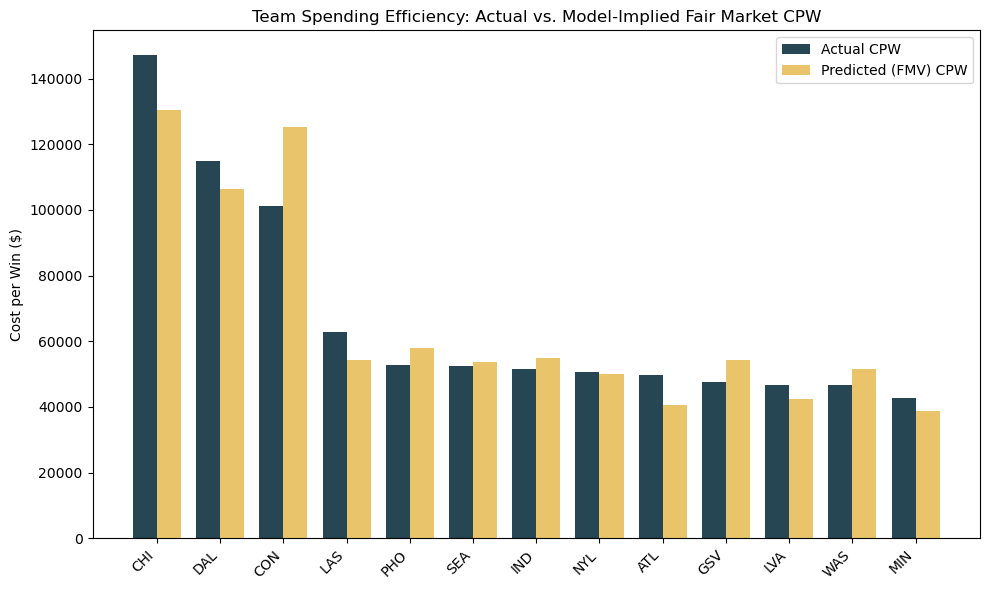

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(team_cpw))
width = 0.38

ax.bar(x - width / 2, team_cpw["actual_cpw"], width, label="Actual CPW", color="#264653")
ax.bar(x + width / 2, team_cpw["predicted_cpw"], width, label="Predicted (FMV) CPW", color="#e9c46a")

ax.set_xticks(x)
ax.set_xticklabels(team_cpw.index, rotation=45, ha="right")
ax.set_ylabel("Cost per Win ($)")
ax.set_title("Team Spending Efficiency: Actual vs. Model-Implied Fair Market CPW")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "team_cpw_comparison.png", dpi=150)
plt.show()


### Most & Least Efficient Spenders

`cpw_gap = actual_cpw - predicted_cpw`. A **negative** gap means a team is paying *less* per win
than the model's fair-value estimate implies, so they are getting wins cheaply, i.e. **efficient** spending.
A **positive** gap means a team is paying *more* per win than fair value would justify, so they are
overspending relative to what its win total earned, i.e. **inefficient** spending.


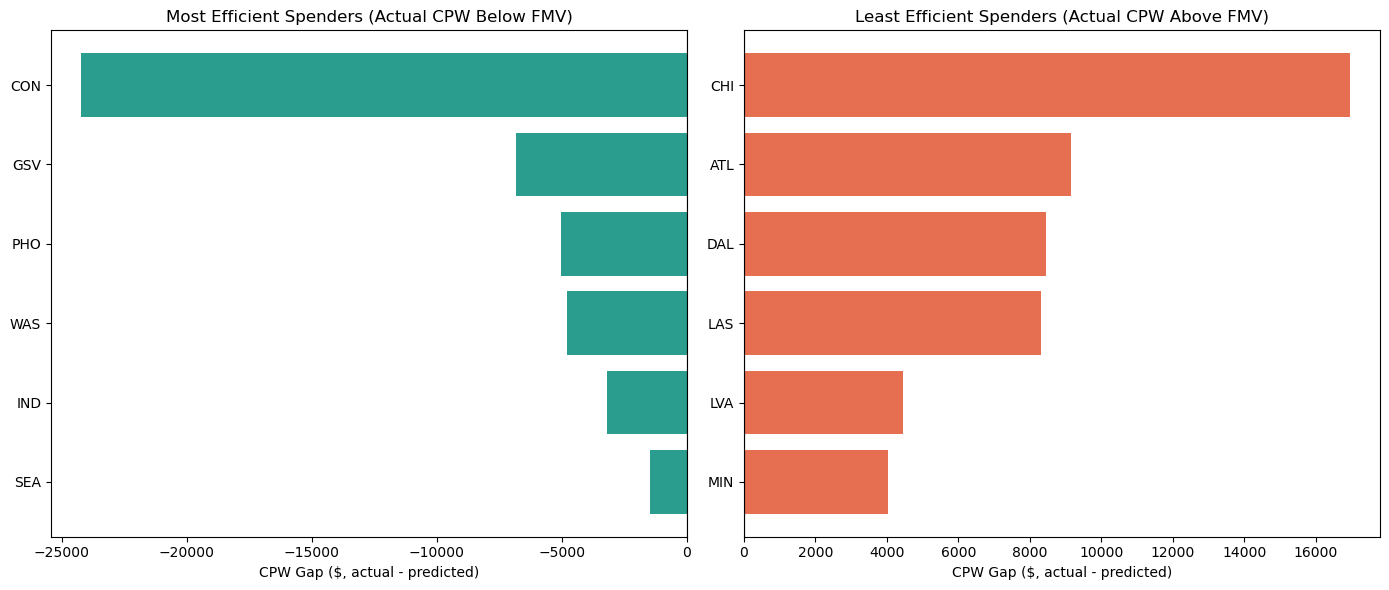

,team_wins,actual_cpw,predicted_cpw,cpw_gap
team,,,,
CON,11.0,101140.909091,125357.306017,-24216.396927
GSV,23.0,47492.652174,54309.989987,-6817.337813
PHO,27.0,52823.703704,57859.082635,-5035.378931
WAS,16.0,46664.562500,51447.959414,-4783.396914
IND,24.0,51681.416667,54868.734951,-3187.318284
SEA,23.0,52320.086957,53782.946572,-1462.859615


,team_wins,actual_cpw,predicted_cpw,cpw_gap
team,,,,
CHI,10.0,147319.700000,130368.153029,16951.546971
ATL,30.0,49697.833333,40550.314035,9147.519298
DAL,10.0,114788.500000,106331.663508,8456.836492
LAS,21.0,62683.666667,54379.855001,8303.811666
LVA,30.0,46728.766667,42285.464680,4443.301986
MIN,34.0,42789.705882,38761.877901,4027.827982


In [13]:
top_n = min(6, max(1, len(team_cpw) // 2))

most_efficient = team_cpw.sort_values("cpw_gap").head(top_n)
least_efficient = team_cpw.sort_values("cpw_gap", ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

axes[0].barh(most_efficient.index, most_efficient["cpw_gap"], color="#2a9d8f")
axes[0].invert_yaxis()
axes[0].set_title("Most Efficient Spenders (Actual CPW Below FMV)")
axes[0].set_xlabel("CPW Gap ($, actual - predicted)")
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(least_efficient.index, least_efficient["cpw_gap"], color="#e76f51")
axes[1].invert_yaxis()
axes[1].set_title("Least Efficient Spenders (Actual CPW Above FMV)")
axes[1].set_xlabel("CPW Gap ($, actual - predicted)")
axes[1].axvline(0, color="black", linewidth=0.8)

fig.tight_layout()
fig.savefig(figures_dir / "team_efficiency_leaderboard.png", dpi=150)
plt.show()

display(most_efficient[["team_wins", "actual_cpw", "predicted_cpw", "cpw_gap"]])
display(least_efficient[["team_wins", "actual_cpw", "predicted_cpw", "cpw_gap"]])


## Feature Importance

An interpretability chart for non-technical stakeholders (GMs, agents).


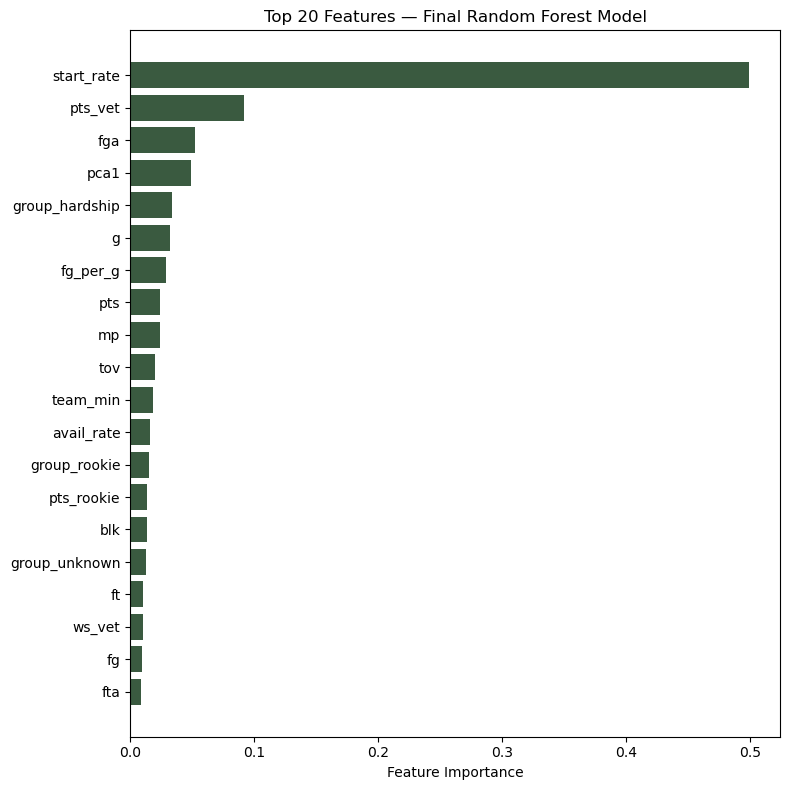

,importance
start_rate,0.498838
pts_vet,0.091752
fga,0.052493
pca1,0.048974
group_hardship,0.033800
g,0.031985
fg_per_g,0.028566
pts,0.024006
mp,0.023794
tov,0.020338


In [14]:
importances = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)
top_importances = importances.head(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_importances.index, top_importances.values, color="#3a5a40")
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Features — Final Random Forest Model")
fig.tight_layout()
fig.savefig(figures_dir / "feature_importance.png", dpi=150)
plt.show()

display(top_importances.to_frame("importance"))


## Lift Analysis: Model vs Baseline Performance

In [15]:
baseline_data = {
    "Model Architecture": [
        "Dummy Heuristic (Mean)",
        "Single-Feature Baseline (pts)",
        "Linear Regression (OLS)",
        "Ridge Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "Baseline RMSE": [69597.131729, 48794.201500, 52720.092685, 49780.306324, 56171.981342, 44850.440577],
    "Baseline CPWS MAE": [141172.69, 69277.75, 34313.41, 36609.21, 55335.94, 25573.41]
}

df_lift = pd.DataFrame(baseline_data)

final_rmse = 44850.44    # <-- REPLACE WITH YOUR ACTUAL FINAL PIPELINE RMSE
final_cpws_mae = 25573.41  # <-- REPLACE WITH YOUR ACTUAL FINAL PIPELINE CPWS MAE

df_lift["Final RMSE"] = final_rmse
df_lift["RMSE Lift (%)"] = ((df_lift["Baseline RMSE"] - df_lift["Final RMSE"]) / df_lift["Baseline RMSE"]) * 100

df_lift["Final CPWS MAE"] = final_cpws_mae
df_lift["CPWS MAE Lift (%)"] = ((df_lift["Baseline CPWS MAE"] - df_lift["Final CPWS MAE"]) / df_lift["Baseline CPWS MAE"]) * 100

df_lift_display = df_lift.copy()
for col in ["Baseline RMSE", "Final RMSE"]:
    df_lift_display[col] = df_lift_display[col].map("{:,.2f}".format)
for col in ["Baseline CPWS MAE", "Final CPWS MAE"]:
    df_lift_display[col] = df_lift_display[col].map("${:,.2f}".format)
    
df_lift_display["RMSE Lift (%)"] = df_lift_display["RMSE Lift (%)"].map("{:+.2f}%".format)
df_lift_display["CPWS MAE Lift (%)"] = df_lift_display["CPWS MAE Lift (%)"].map("{:+.2f}%".format)

print("Summary Matrix: Final Pipeline Performance Lift")
df_lift_display[[
    "Model Architecture", 
    "Baseline RMSE", "Final RMSE", "RMSE Lift (%)", 
    "Baseline CPWS MAE", "Final CPWS MAE", "CPWS MAE Lift (%)"
]]

Summary Matrix: Final Pipeline Performance Lift


,Model Architecture,Baseline RMSE,Final RMSE,RMSE Lift (%),Baseline CPWS MAE,Final CPWS MAE,CPWS MAE Lift (%)
0,Dummy Heuristic (Mean),"69,597.13","44,850.44",+35.56%,"$141,172.69","$25,573.41",+81.89%
1,Single-Feature Baseline (pts),"48,794.20","44,850.44",+8.08%,"$69,277.75","$25,573.41",+63.09%
2,Linear Regression (OLS),"52,720.09","44,850.44",+14.93%,"$34,313.41","$25,573.41",+25.47%
3,Ridge Regression,"49,780.31","44,850.44",+9.90%,"$36,609.21","$25,573.41",+30.14%
4,Decision Tree Regressor,"56,171.98","44,850.44",+20.16%,"$55,335.94","$25,573.41",+53.79%
5,Random Forest Regressor,"44,850.44","44,850.44",+0.00%,"$25,573.41","$25,573.41",+0.00%


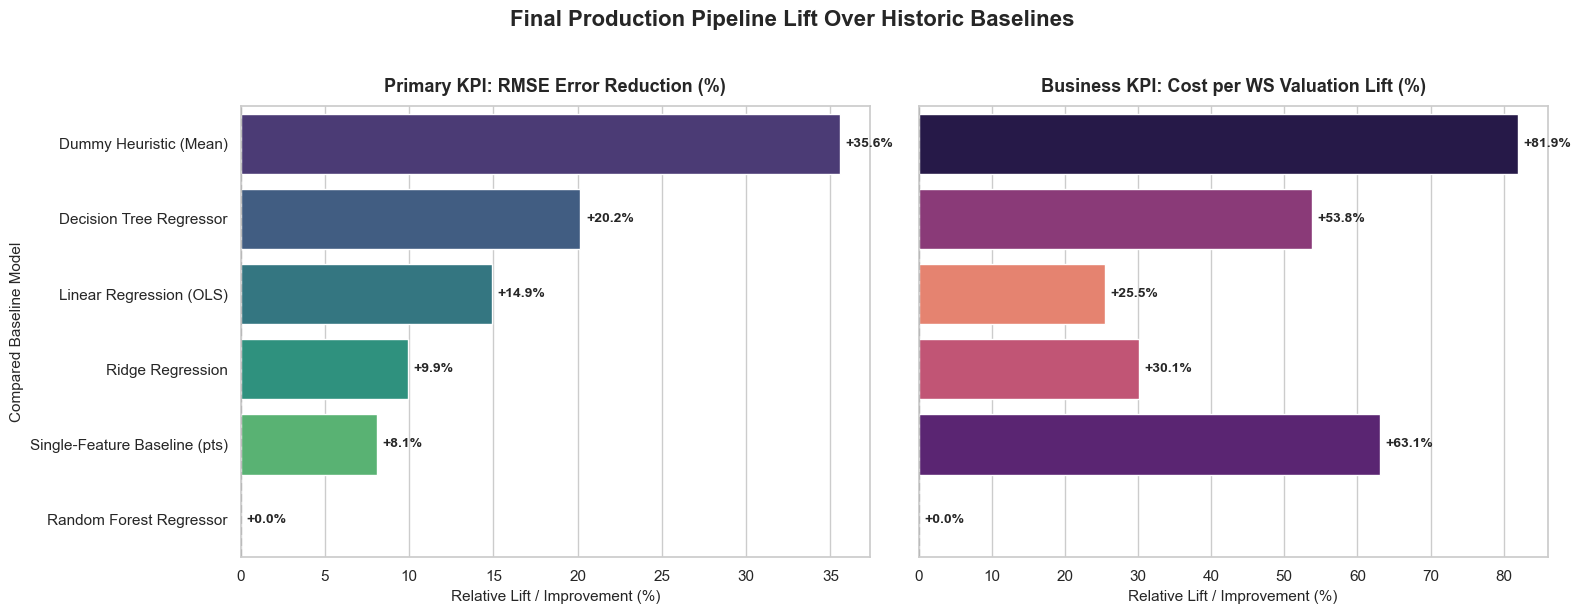

In [16]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

df_sorted_rmse = df_lift.sort_values(by="RMSE Lift (%)", ascending=False)
df_sorted_cpws = df_lift.sort_values(by="CPWS MAE Lift (%)", ascending=False)

sns.barplot(
    x="RMSE Lift (%)", 
    y="Model Architecture", 
    hue="Model Architecture",
    data=df_sorted_rmse, 
    palette="viridis", 
    legend=False,
    ax=axes[0]
)
axes[0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Primary KPI: RMSE Error Reduction (%)", fontsize=13, fontweight="bold", pad=10)
axes[0].set_xlabel("Relative Lift / Improvement (%)", fontsize=11)
axes[0].set_ylabel("Compared Baseline Model", fontsize=11)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:+.1f}%', padding=4, fontweight="bold", size=10)


sns.barplot(
    x="CPWS MAE Lift (%)", 
    y="Model Architecture", 
    hue="Model Architecture",
    data=df_sorted_cpws, 
    palette="magma", 
    legend=False,
    ax=axes[1]
)
axes[1].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[1].set_title("Business KPI: Cost per WS Valuation Lift (%)", fontsize=13, fontweight="bold", pad=10)
axes[1].set_xlabel("Relative Lift / Improvement (%)", fontsize=11)
axes[1].set_ylabel("")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:+.1f}%', padding=4, fontweight="bold", size=10)

plt.suptitle("Final Production Pipeline Lift Over Historic Baselines", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Save Enriched Player-Level Table

The `value_pct` / `valuation_tag` / `team_wins` columns added in this notebook are saved as a
separate enriched file rather than overwriting `final_predictions.csv`, so the original pipeline
output stays untouched and reproducible on its own.


In [17]:
enriched_path = final_result_dir / "final_predictions_enriched.csv"
pred_df.to_csv(enriched_path, index=False)
print(f"Saved enriched player-level predictions to {enriched_path}")


Saved enriched player-level predictions to /Users/elenaaxinn/Desktop/project/results/final_predictions_enriched.csv
